# Notebook 12 — MLP + LightGBM AG + SMOTE (features M3)
**Desempenho Socioeconômico no ENEM (2012–2024)**

## O que mudou em relação aos notebooks anteriores

| Problema anterior | Solução aqui |
|---|---|
| Features fracas (só 8 vars) | **M3**: adiciona `idhm_branco/negro/homem/mulher` + `SG_UF_ESC` (21 features) |
| Modelo prevê só classe majoritária | **SMOTE**: oversample da classe `Alto` até balancear |
| LinearSVC não captura não-linearidades | **MLP** (256→128→64) e **LightGBM** com AG |
| LightGBM com defaults | **AG** sobre 4 hiperparâmetros: `n_estimators`, `num_leaves`, `lr`, `min_child` |

**Q003–Q025 não estão no dataset** (foram dropados na limpeza). Para adicioná-los seria necessário re-rodar os notebooks 01–04 a partir dos CSVs brutos do ENEM.

| Seção | Conteúdo |
|---|---|
| 0 | Setup |
| 1 | Carregamento via DuckDB (M3 features) |
| 2 | Pré-processamento e split |
| 3 | SMOTE — balanceamento de classes |
| 4 | MLP |
| 5 | LightGBM + AG |
| 6 | Comparação e figuras |
| 7 | Persistência |

## Seção 0 — Setup

In [5]:
import warnings
warnings.filterwarnings('ignore')
import subprocess, gc, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, duckdb

# instala dependências opcionais se necessário
for pkg in ['imbalanced-learn', 'lightgbm']:
    try:
        __import__(pkg.replace('-','_').split('.')[0])
    except ImportError:
        subprocess.run(['pip', 'install', '-q', pkg], check=True)
        print(f'Instalado: {pkg}')

import lightgbm as lgb
from imblearn.over_sampling import SMOTE

from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
N_SAMPLE     = 1_000_000
DATA_DIR     = '../data/processed'
MODELS_DIR   = '../data/models'
FIGS_DIR     = DATA_DIR
PARQUET      = f'{DATA_DIR}/dataset_analitico.parquet'
os.makedirs(MODELS_DIR, exist_ok=True)

FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# AG para LightGBM
GA_POP=20; GA_GENS=15; GA_CXPB=0.70; GA_MUTPB=0.30
GA_TOUR=3; GA_ELITE=2; GA_SUB=50_000; GA_SUBV=10_000; GA_SEED=42

print(f'LightGBM {lgb.__version__} | imbalanced-learn OK')
print(f'N_SAMPLE={N_SAMPLE:,}')

Instalado: imbalanced-learn
LightGBM 4.6.0 | imbalanced-learn OK
N_SAMPLE=1,000,000


## Seção 1 — Carregamento via DuckDB (features M3)

**Novos features em relação a notebooks anteriores:**
- `idhm_branco`, `idhm_negro`, `idhm_homem`, `idhm_mulher` — IDHM desagregado por raça/gênero
- `SG_UF_ESC` — estado da escola (27 UFs vs 5 macrorregiões = mais granular)

In [6]:
con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, SG_UF_ESC, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        -- IDHM estadual geral (M2)
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- IDHM desagregado por raça/gênero
        idhm_branco, idhm_negro, idhm_homem, idhm_mulher,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        -- target
        CASE
            WHEN FAIXA_MT IN ('<400','400-500')    THEN 0
            WHEN FAIXA_MT IN ('500-600','600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800','>800')    THEN 2
        END::TINYINT AS y_mt
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra: {len(df):,} registros')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra: 277,460 registros
  Baixo (<500): 145,077 (52.3%)
  Médio (500–700): 112,605 (40.6%)
  Alto (>700): 19,778 (7.1%)


## Seção 2 — Pré-processamento e Split

In [7]:
UF_MAP = {uf: i for i, uf in enumerate(sorted(df['SG_UF_ESC'].dropna().unique()))}

df['tp_sexo']   = df['TP_SEXO'].map({'F':0,'0':0,'M':1,'1':1})
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'],   errors='coerce')
df['q001']      = df['Q001'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q002']      = df['Q002'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q006']      = df['Q006_HARM'].map({c:i for i,c in enumerate('ABCDE')})
df['regiao']    = df['REGIAO'].map({'Norte':0,'Nordeste':1,'Centro-Oeste':2,'Sul':3,'Sudeste':4})
df['uf']        = df['SG_UF_ESC'].map(UF_MAP)
df['ano']       = df['NU_ANO'].astype('float32')

# Encoding Q estendidas
def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

# Conjuntos de features
FEATS_BASE = ['tp_sexo','tp_cor','tp_escola','q001','q002','q006','regiao','uf','ano']
FEATS_IDHM = [
    'idhm','idhm_educacao','idhm_renda','idhm_longevidade',
    'renda_percapita','tx_analfabetismo','tx_envelhecimento',
    'esperanca_vida','mortalidade_infantil'
]
FEATS_DESG  = ['idhm_branco','idhm_negro','idhm_homem','idhm_mulher']  # IDHM desagregado
FEATS_Q_EXT = [
    'q_ocup_pai','q_ocup_mae','q_n_pessoas','q_empregada',
    'q_carro','q_moto','q_geladeira','q_lavadora','q_tv',
    'q_computador','q_internet','q_celular','q_tipo_esc_em','q_bolsa_fam'
]

# M3 = BASE + Q_EXT (questões individuais do questionário — mais informativas que IDHM agregado)
# M4 = BASE + IDHM + IDHM_DESG + Q_EXT (tudo)
FEATS_M3 = FEATS_BASE + FEATS_Q_EXT
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_DESG + FEATS_Q_EXT

X = df[FEATS_M4].values.astype('float32')
y = df['y_mt'].values.astype('int8')
del df; gc.collect()

# 80% treino / 20% val
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
del X; gc.collect()

print(f'Features: M3={len(FEATS_M3)} | M4={len(FEATS_M4)}')
print(f'  BASE={len(FEATS_BASE)} | IDHM={len(FEATS_IDHM)} | DESG={len(FEATS_DESG)} | Q_EXT={len(FEATS_Q_EXT)}')
print(f'Treino: {len(y_tr):,} | Val: {len(y_val):,}')
print('\nClasses treino:')
for c, l in FAIXA_MAP_INV.items():
    n=(y_tr==c).sum(); print(f'  {l}: {n:,} ({n/len(y_tr)*100:.1f}%)')


Features: M3=23 | M4=36
  BASE=9 | IDHM=9 | DESG=4 | Q_EXT=14
Treino: 221,968 | Val: 55,492

Classes treino:
  Baixo (<500): 116,062 (52.3%)
  Médio (500–700): 90,084 (40.6%)
  Alto (>700): 15,822 (7.1%)


## Seção 3 — SMOTE (balanceamento de classes)

**Por que o modelo prevê só a classe majoritária?**  
Baixo ≈ 52%, Médio ≈ 41%, Alto ≈ 7%. O modelo minimiza o erro total ignorando Alto.

**SMOTE** (Synthetic Minority Oversampling Technique) gera exemplos sintéticos da classe
minoritária por interpolação entre vizinhos reais — mais robusto que duplicação simples.

Aplicado **somente no treino** para não contaminar a validação.

In [8]:
# Imputa NaN antes do SMOTE (SMOTE não aceita NaN)
imp = SimpleImputer(strategy='median')
X_tr_imp = imp.fit_transform(X_tr)
X_val_imp = imp.transform(X_val)

print('Classes antes do SMOTE:')
for c, l in FAIXA_MAP_INV.items():
    n=(y_tr==c).sum(); print(f'  {l}: {n:,} ({n/len(y_tr)*100:.1f}%)')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
print('\nAplicando SMOTE...')
t0 = time.time()
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_imp, y_tr)
print(f'SMOTE OK — {(time.time()-t0):.1f}s')

print('\nClasses após SMOTE:')
for c, l in FAIXA_MAP_INV.items():
    n=(y_tr_sm==c).sum(); print(f'  {l}: {n:,} ({n/len(y_tr_sm)*100:.1f}%)')
print(f'Total treino após SMOTE: {len(y_tr_sm):,}')

Classes antes do SMOTE:
  Baixo (<500): 116,062 (52.3%)
  Médio (500–700): 90,084 (40.6%)
  Alto (>700): 15,822 (7.1%)

Aplicando SMOTE...
SMOTE OK — 12.9s

Classes após SMOTE:
  Baixo (<500): 116,062 (33.3%)
  Médio (500–700): 116,062 (33.3%)
  Alto (>700): 116,062 (33.3%)
Total treino após SMOTE: 348,186


## Seção 4 — MLP

Rede simples 3 camadas ocultas (256 → 128 → 64) com ReLU e regularização L2.
Captura interações não-lineares entre features que SVM linear não consegue.

In [9]:
# StandardScaler nos dados já imputados
sc = StandardScaler()
X_tr_sc  = sc.fit_transform(X_tr_sm)   # escala os dados com SMOTE
X_val_sc = sc.transform(X_val_imp)

print('Treinando MLP (256→128→64)...')
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    alpha=1e-4,           # regularização L2
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
    verbose=False
)
mlp.fit(X_tr_sc, y_tr_sm)
yp_mlp = mlp.predict(X_val_sc)
mlp_f1 = f1_score(y_val, yp_mlp, average='macro')
print(f'MLP — Macro F1: {mlp_f1:.4f}  |  {(time.time()-t0)/60:.1f} min')
print(f'Épocas: {mlp.n_iter_}')
print(classification_report(y_val, yp_mlp, target_names=FAIXA_ORDER))

Treinando MLP (256→128→64)...
MLP — Macro F1: 0.5081  |  9.0 min
Épocas: 78
                 precision    recall  f1-score   support

   Baixo (<500)       0.69      0.68      0.68     29015
Médio (500–700)       0.52      0.48      0.50     22521
    Alto (>700)       0.28      0.44      0.34      3956

       accuracy                           0.58     55492
      macro avg       0.50      0.53      0.51     55492
   weighted avg       0.59      0.58      0.59     55492



## Seção 5 — LightGBM + AG

AG otimiza 4 hiperparâmetros do LightGBM num subset de 50k para manter cada
avaliação rápida (~2–3s). Modelo final treinado nos dados completos com SMOTE.

| Gene | Parâmetro | Range |
|---|---|---|
| 0 | `n_estimators` | [50, 600] |
| 1 | `num_leaves` | [15, 127] |
| 2 | `learning_rate` | [0.01, 0.3] (log) |
| 3 | `min_child_samples` | [10, 100] |

In [10]:
# Subsets para AG (sem SMOTE — LightGBM lida com desbalanceamento via class_weight)
_, X_sub, _, y_sub = train_test_split(X_tr_imp, y_tr, test_size=GA_SUB,
                                       stratify=y_tr, random_state=RANDOM_STATE)
_, X_subv, _, y_subv = train_test_split(X_val_imp, y_val, test_size=GA_SUBV,
                                         stratify=y_val, random_state=RANDOM_STATE)

# Bounds dos genes: [n_est_min, nl_min, lr_min, mc_min]
LO = np.array([50,  15, np.log(0.01), 10])
HI = np.array([600, 127, np.log(0.30), 100])

def decode_lgb(ind):
    n_est = int(round(np.clip(ind[0], LO[0], HI[0])))
    nl    = int(round(np.clip(ind[1], LO[1], HI[1])))
    lr    = float(np.exp(np.clip(ind[2], LO[2], HI[2])))
    mc    = int(round(np.clip(ind[3], LO[3], HI[3])))
    return n_est, nl, lr, mc

def lgb_fitness(ind, Xtr, Xv, ytr, yv):
    n_est, nl, lr, mc = decode_lgb(ind)
    try:
        m = lgb.LGBMClassifier(n_estimators=n_est, num_leaves=nl, learning_rate=lr,
                                min_child_samples=mc, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=1, verbosity=-1)
        m.fit(Xtr, ytr)
        return f1_score(yv, m.predict(Xv), average='macro')
    except Exception:
        return 0.0

def evolve_lgb():
    rng  = np.random.default_rng(GA_SEED)
    pop  = np.column_stack([rng.uniform(lo, hi, GA_POP) for lo, hi in zip(LO, HI)])
    fits = np.array([lgb_fitness(i, X_sub, X_subv, y_sub, y_subv) for i in pop])
    hist = [fits.max()]
    p = decode_lgb(pop[fits.argmax()])
    print(f'Gen  0 — best={fits.max():.4f}  n_est={p[0]} nl={p[1]} lr={p[2]:.3f} mc={p[3]}')
    for gen in range(1, GA_GENS+1):
        elite   = list(pop[np.argsort(fits)[-GA_ELITE:]])
        new_pop = elite[:]
        while len(new_pop) < GA_POP:
            def tour(): idx=rng.integers(0,len(pop),GA_TOUR); return pop[idx[np.argmax(fits[idx])]].copy()
            p1, p2 = tour(), tour()
            if rng.random() < GA_CXPB:
                m = rng.random(4) < 0.5
                c1, c2 = np.where(m,p1,p2), np.where(m,p2,p1)
            else:
                c1, c2 = p1.copy(), p2.copy()
            for c in [c1, c2]:
                if rng.random() < GA_MUTPB:
                    c += rng.normal(0, (HI - LO) * 0.1)
                    c[:] = np.clip(c, LO, HI)
            new_pop.append(c1)
            if len(new_pop) < GA_POP: new_pop.append(c2)
        pop  = np.array(new_pop)
        fits = np.array([lgb_fitness(i, X_sub, X_subv, y_sub, y_subv) for i in pop])
        hist.append(fits.max())
        p = decode_lgb(pop[fits.argmax()])
        print(f'Gen {gen:2d} — best={fits.max():.4f}  n_est={p[0]} nl={p[1]} lr={p[2]:.3f} mc={p[3]}  mean={fits.mean():.4f}')
    bi = fits.argmax()
    return pop[bi], fits[bi], hist

print('=== AG — LightGBM ===')
t0 = time.time()
best_lgb_ind, best_lgb_fit, hist_lgb = evolve_lgb()
best_n, best_nl, best_lr, best_mc = decode_lgb(best_lgb_ind)
print(f'\nMelhor: n_est={best_n} nl={best_nl} lr={best_lr:.4f} mc={best_mc}')
print(f'Fitness subset: {best_lgb_fit:.4f}  |  {(time.time()-t0)/60:.1f} min')

=== AG — LightGBM ===
Gen  0 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79
Gen  1 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5178
Gen  2 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5198
Gen  3 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5209
Gen  4 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5206
Gen  5 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5217
Gen  6 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5222
Gen  7 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5216
Gen  8 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5215
Gen  9 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5220
Gen 10 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5208
Gen 11 — best=0.5226  n_est=434 nl=115 lr=0.029 mc=79  mean=0.5202
Gen 12 — best=0.5230  n_est=440 nl=115 lr=0.018 mc=79  mean=0.5206
Gen 13 — best=0.5230  n_est=440 nl=115 lr=0.018 mc=79  mean=0.5217
Gen 14 — best=0.5230  n_est=440 nl=115 lr=0.018 mc=79

In [11]:
# Treino final — dados COMPLETOS com SMOTE
print('Treinando LightGBM final (dados completos + SMOTE)...')
t0 = time.time()
lgb_final = lgb.LGBMClassifier(
    n_estimators=best_n, num_leaves=best_nl, learning_rate=best_lr,
    min_child_samples=best_mc, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=1, verbosity=-1
)
lgb_final.fit(X_tr_sm, y_tr_sm)    # dados pós-SMOTE (já imputados)
yp_lgb = lgb_final.predict(X_val_imp)
lgb_f1 = f1_score(y_val, yp_lgb, average='macro')
print(f'LightGBM+AG+SMOTE — Macro F1: {lgb_f1:.4f}  |  {(time.time()-t0):.1f}s')
print(classification_report(y_val, yp_lgb, target_names=FAIXA_ORDER))

Treinando LightGBM final (dados completos + SMOTE)...
LightGBM+AG+SMOTE — Macro F1: 0.5406  |  98.7s
                 precision    recall  f1-score   support

   Baixo (<500)       0.69      0.75      0.72     29015
Médio (500–700)       0.56      0.51      0.53     22521
    Alto (>700)       0.40      0.34      0.37      3956

       accuracy                           0.62     55492
      macro avg       0.55      0.53      0.54     55492
   weighted avg       0.62      0.62      0.62     55492



## Seção 6 — Comparação e Figuras

In [12]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr_imp, y_tr)
yp_dummy = dummy.predict(X_val_imp)

modelos = [
    ('Baseline (majority)',       yp_dummy),
    ('MLP 256→128→64 + SMOTE',   yp_mlp),
    ('LightGBM+AG+SMOTE',        yp_lgb),
]

rows = []
for nome, yp in modelos:
    rows.append([
        nome,
        accuracy_score(y_val, yp),
        f1_score(y_val, yp, average='macro'),
        f1_score(y_val, yp, average='weighted'),
        f1_score(y_val, yp, average=None, labels=[0,1,2])[2],  # F1 classe Alto
    ])
df_res = pd.DataFrame(rows, columns=['Modelo','Accuracy','Macro F1','Weighted F1','F1 Alto'])
print('=== Comparação — FAIXA_MT 3 classes (validation set) ===')
print(df_res.to_string(index=False))

=== Comparação — FAIXA_MT 3 classes (validation set) ===
                Modelo  Accuracy  Macro F1  Weighted F1  F1 Alto
   Baseline (majority)  0.522868  0.228896     0.359048 0.000000
MLP 256→128→64 + SMOTE  0.581561  0.508087     0.585259 0.339226
     LightGBM+AG+SMOTE  0.623946  0.540614     0.618787 0.369281


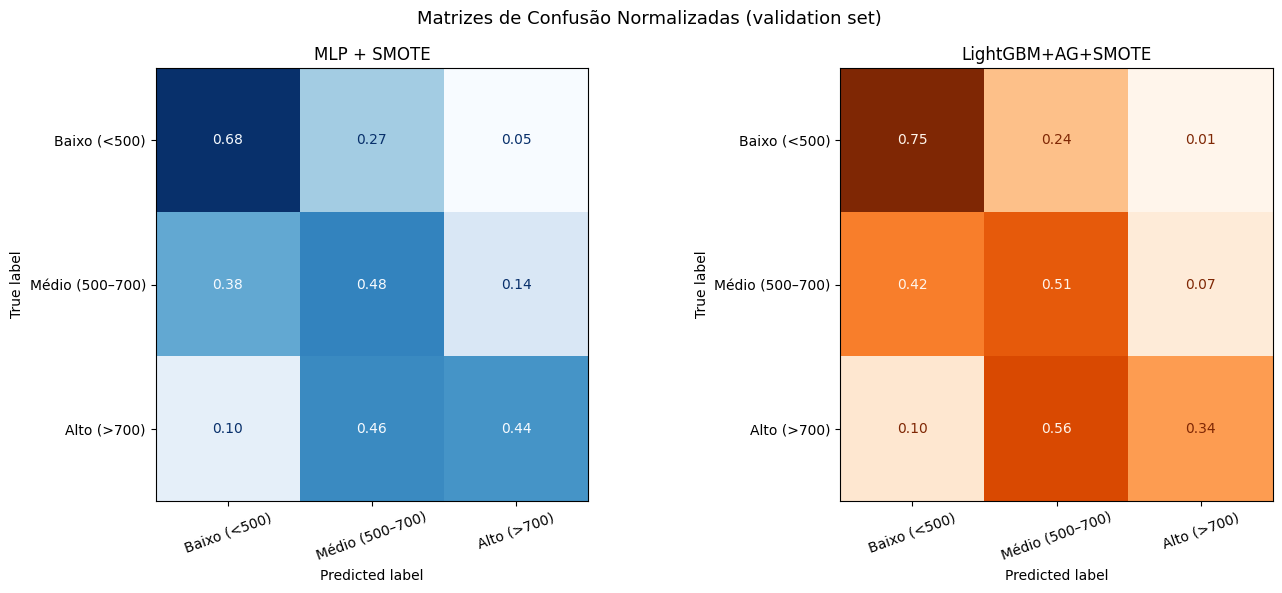

Salvo: fig_12_cm.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (nome, yp), cmap in zip(
    axes,
    [('MLP + SMOTE', yp_mlp), ('LightGBM+AG+SMOTE', yp_lgb)],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_val, yp, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER).plot(
        ax=ax, cmap=cmap, colorbar=False, values_format='.2f'
    )
    ax.set_title(nome)
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Matrizes de Confusão Normalizadas (validation set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_12_cm.png', dpi=150)
plt.show()
print('Salvo: fig_12_cm.png')

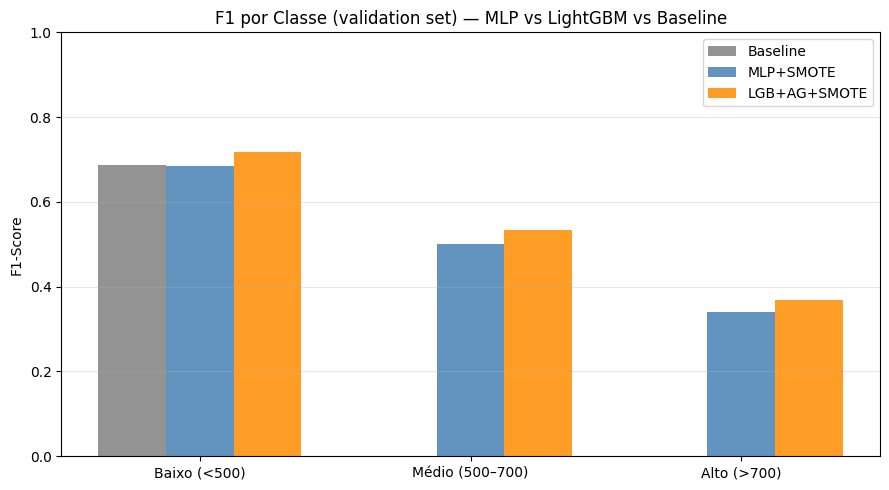

Salvo: fig_12_f1_classe.png


In [14]:
modelos_plot = [
    ('Baseline',    yp_dummy, 'gray'),
    ('MLP+SMOTE',   yp_mlp,   'steelblue'),
    ('LGB+AG+SMOTE',yp_lgb,   'darkorange'),
]
x, w = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, (nome, yp, cor) in enumerate(modelos_plot):
    f1s = f1_score(y_val, yp, average=None, labels=[0,1,2])
    ax.bar(x + (i-1)*w, f1s, w, label=nome, color=cor, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('F1 por Classe (validation set) — MLP vs LightGBM vs Baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_12_f1_classe.png', dpi=150)
plt.show()
print('Salvo: fig_12_f1_classe.png')

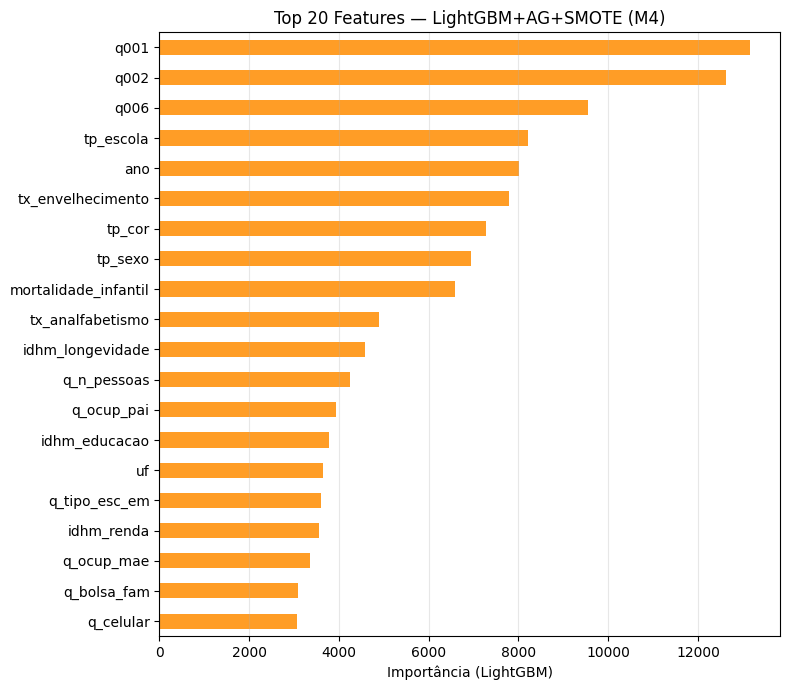

Salvo: fig_12_feature_importance.png


In [15]:
importances = lgb_final.feature_importances_
feat_imp = pd.Series(importances, index=FEATS_M4).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp.plot(kind='barh', ax=ax, color='darkorange', alpha=0.85)
ax.set_xlabel('Importância (LightGBM)')
ax.set_title('Top 20 Features — LightGBM+AG+SMOTE (M4)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_12_feature_importance.png', dpi=150)
plt.show()
print('Salvo: fig_12_feature_importance.png')


## Seção 7 — Persistência

In [16]:
# Salva o pipeline completo MLP (imputer + scaler + mlp)
pipe_mlp_full = Pipeline([
    ('imp', imp),
    ('sc',  sc),
    ('mlp', mlp)
])
joblib.dump(pipe_mlp_full, f'{MODELS_DIR}/mlp_smote_m4.pkl')
joblib.dump(lgb_final,     f'{MODELS_DIR}/lgb_ag_smote_m4.pkl')
joblib.dump(imp,           f'{MODELS_DIR}/imputer_m4.pkl')
joblib.dump(sc,            f'{MODELS_DIR}/scaler_m4.pkl')
joblib.dump({
    'feats_m3': FEATS_M3,
    'feats_m4': FEATS_M4,
    'uf_map': UF_MAP,
    'lgb_params': {'n_estimators':best_n,'num_leaves':best_nl,'learning_rate':best_lr,'min_child_samples':best_mc},
    'ag_history': hist_lgb,
    'results': df_res,
}, f'{MODELS_DIR}/nb12_results.pkl')

print('Salvos:')
for f in ['mlp_smote_m4.pkl','lgb_ag_smote_m4.pkl','nb12_results.pkl']:
    print(f'  data/models/{f}')

print('\n=== RESUMO FINAL ===')
print(df_res.to_string(index=False))


Salvos:
  data/models/mlp_smote_m4.pkl
  data/models/lgb_ag_smote_m4.pkl
  data/models/nb12_results.pkl

=== RESUMO FINAL ===
                Modelo  Accuracy  Macro F1  Weighted F1  F1 Alto
   Baseline (majority)  0.522868  0.228896     0.359048 0.000000
MLP 256→128→64 + SMOTE  0.581561  0.508087     0.585259 0.339226
     LightGBM+AG+SMOTE  0.623946  0.540614     0.618787 0.369281
